# Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Data Importation (Google Drive)

In [2]:
df=pd.read_csv("/content/drive/MyDrive/houses-for-sale.csv")
df.head(10)

,title,location,size,selling price
0,6 Bed Villa with En Suite at Kiambu Road,Kiambu Road,"6bdrm Mansion in Mushroom Estate, Kiambu / Kia...","KSh 130,000,000"
1,4 Bed Townhouse with En Suite at Off Kiambu Road,"Off Kiambu Road, Kiambu Road",4 Bedroom with DSQ for Sale,"KSh 26,950,000"
2,4 Bed Villa with En Suite at Masai Lodge Road,"masai lodge road, Ongata Rongai",New modern villa for sale.,"KSh 16,000,000"
3,5 Bed House with En Suite in Ngong Road,Ngong Road,5 Bedroom Town House For Sale In Kilimani,"KSh 45,000,000"
4,5 Bed Townhouse with En Suite in Lavington,Lavington,Modern 5 Bedroom Townhouse For Sale,"KSh 72,000,000"
5,5 Bed Townhouse with En Suite at Grevallia,"grevallia, Spring Valley, Westlands",5 Bedroom Townhouse For Sale,"KSh 46,000,000"
6,5 Bed House with En Suite in Lavington,Lavington,Rustic 5 Bedroom house For Sale on 1/4 of an a...,"KSh 85,000,000"
7,5 Bed Townhouse with En Suite in Kileleshwa,Kileleshwa,5 Bedroom Town House For sale,"KSh 50,000,000"
8,5 Bed Townhouse with En Suite in Lavington,Lavington,Modern 5 Bedroom Town House Plus Dsq,"KSh 75,000,000"
9,5 Bed House with En Suite at Rusinga Court,"Rusinga Court, Lavington",5 BEDROOM ALL ENSUITE FOR SALE IN LAVINGTON,"KSh 500,000,000"


# Data Cleaning & Creating New Features



In [3]:
# Selling Price datatype is cleaned and converted to int64 datatype
df = df.drop(df[df["selling price"] == "Price not communicated"].index)
df['selling price']=(df['selling price']
                     .str.replace('KSh','')
                     .str.replace(',','')
                     .astype(int)
)


In [4]:
# RegEx breakdown: Find a digit (\d+), optional space (\s*), then "bed" or "bdrm" or "bedroom"
bedroom_regex = r'(\d+)\s*(?:bed|bdrm|bedroom)'

# Extract from title (ignore case to handle 'Bed' vs 'bed')
df['no_of_bedrooms'] = df['title'].str.extract(bedroom_regex, flags=re.IGNORECASE).astype(float)

In [5]:
df["has_servant_quarters"] = df["size"].str.contains(r"dsq", flags=re.IGNORECASE, na=False).astype(int)

In [6]:
def classify_property_type(text):
  text=str(text).lower()
  if "townhouse" in text or "town house" in text:
    return "Townhouse"
  elif "Apartment" in text or "flat" in text:
    return "Flat"
  elif "house" in text or "villa" in text:
    return "Villa"
  elif "mansion" in text:
    return "Mansion"
  else:
    return "Other"
df["property_type"]=df["title"].apply(classify_property_type)

In [7]:

def master_location_cleaner(loc_str):
    if not isinstance(loc_str, str):
        return 'Other'

    # 1. Standardize formatting and handle common spelling disasters
    loc = loc_str.lower().strip()
    loc = re.sub(r'gr[ie]v[e|a]ll?ia\s*gro[v|o]e?', 'grevillea', loc)

    # 2. Sequential mapping logic (ALL KEYWORDS MUST BE LOWERCASE)
    if any(k in loc for k in ['kiambu road', 'edenville', 'fourways', 'fivestar', 'ridgeways', 'ruaka', 'muchatha', 'thindigua', 'guango', 'kigwa ridge', 'kiambu town', 'banana']):
        return 'Kiambu Road'
    elif any(k in loc for k in ['lavington', 'chalbi', 'convent', 'apple cross']):
        return 'Lavington'
    elif any(k in loc for k in ['ruiru', 'kamakis', 'membley', 'mugutha']):
        return 'Ruiru'
    elif any(k in loc for k in ['westlands', 'brookside', 'rhapta', 'general mathenge']):
        return 'Westlands'
    elif any(k in loc for k in ['runda', 'mumwe', 'evergreen']):
        return 'Runda'
    elif any(k in loc for k in ['karen', 'hardy', 'bogani', 'miotoni']):
        return 'Karen'
    elif any(k in loc for k in ['nyali', 'links road', 'mkomani']):
        return 'Nyali'
    elif any(k in loc for k in ['mtwapa', 'la-marina', 'aloo drive']):
        return 'Mtwapa'
    elif any(k in loc for k in ['kitengela', 'acacia', 'namanga']):
        return 'Kitengela'
    elif any(k in loc for k in ['kilimani', 'dennis pritt', 'argwings']):
        return 'Kilimani'
    elif any(k in loc for k in ['syokimau', 'katani', 'gateway mall', 'mombasa road', 'mlolongo', 'choma zone', 'bustan villas']):
        return 'Mombasa Road / Syokimau'
    elif any(k in loc for k in ['ngong', 'kerarapon', 'oloolua']):
        return 'Ngong'
    elif any(k in loc for k in ['rongai', 'masai lodge', 'rimpa']):
        return 'Ongata Rongai'
    elif any(k in loc for k in ['kikuyu', 'gikambura', 'ondiri']):
        return 'Kikuyu'
    elif 'kitisuru' in loc:
        return 'Kitisuru'
    elif any(k in loc for k in ['mombasa island', 'kizingo', 'kisauni', 'tudor', 'changamwe', 'bamburi', 'shanzu', 'bombolulu', 'nyerere road']):
        return 'Mombasa'
    elif any(k in loc for k in ['juja', 'kenyatta road', 'kenyatta rd', 'gatundu road']):
        return 'Juja / Kenyatta Road'
    elif any(k in loc for k in ['embakasi', 'utawala', 'pipeline', 'airport road', 'imara daima', 'villa franca','komarock','donholm','buruburu']):
        return 'Embakasi / Eastlands'
    elif any(k in loc for k in ['kisumu', 'municipality']):
        return 'Kisumu'
    elif 'loresho' in loc:
        return 'Loresho'
    elif 'kileleshwa' in loc:
        return 'Kileleshwa'
    elif 'muthaiga' in loc:
        return 'Muthaiga'
    elif any(k in loc for k in ['malindi', 'casaurina']):
        return 'Malindi'
    elif 'watamu' in loc:
        return 'Watamu'
    elif any(k in loc for k in ['diani', 'ukunda']):
        return 'Diani'
    elif 'athi river' in loc:
        return 'Athi River'
    elif 'thika' in loc:
        return 'Thika'
    elif any(k in loc for k in ['roysambu', 'mirema', 'thome', 'kahawa', 'kasarani']):
        return 'Roysambu Area'
    elif 'south c' in loc:
        return 'South C'
    elif 'south b' in loc:
        return 'South B'
    elif any(k in loc for k in ['langa', 'mbagathi', 'nairobi west', 'bukani rd']):
        return "Lang'ata"
    elif 'nanyuki' in loc:
        return 'Nanyuki'
    elif 'naivasha' in loc:
        return 'Naivasha'
    elif any(k in loc for k in ['limuru', 'tigoni', 'redhill']):
        return 'Limuru/Tigoni'
    elif any(k in loc for k in ['kamulu', 'joska', 'malaa', 'kangundo', 'ruai', 'eastern bypass']):
        return 'Kamulu/Joska/Eastern Bypass'
    elif 'gigiri' in loc:
        return 'Gigiri'
    elif any(k in loc for k in ['kilifi', 'bofa', 'vipingo', 'kikambala', 'kanamai']):
        return 'Kilifi/kikambala/Mtwapa'

    return 'Other'

# Clean the dataset again
df['clean_location'] = df['location'].apply(master_location_cleaner)


In [8]:

print(df[df['clean_location'] == 'Other']['location'].unique())

['Kiserian' 'Ngumo Estate' 'Kibera Station road, Jamhuri'
 "Gikono, Murang'a County" 'EPZ, Kajiado County' 'Kamangu' 'Isinya'
 'Oltepesi Kajiado County, Oltepesi, Kiserian'
 '0728m, Dagorretti Corner, Wanyee Road., Dagoretti Corner' 'Githunguri'
 'Nakuru' 'Machakos County' 'Kajiado County' 'Near Pembroke, Gilgil']


In [9]:
df['clean_location'].value_counts()

,count
clean_location,
Westlands,362
Lavington,198
Kiambu Road,133
Kitengela,115
Ruiru,112
Nyali,111
Karen,108
Mombasa Road / Syokimau,74
Mtwapa,58


In [10]:
# STEP 1: Run your cleaning function first to reduce everything to standard names
df['clean_location'] = df['location'].apply(master_location_cleaner)

# STEP 2: Define your updated mapping function with the exact keys returned by master_location_cleaner
def map_to_economic_tiers(clean_loc):
    # These lists must match the exact output strings of master_location_cleaner
    premium_suburbs = ['Westlands', 'Lavington', 'Karen', 'Muthaiga', 'Kileleshwa', 'Kilimani', 'Gigiri', 'Loresho', 'Kitisuru']

    high_density_upcoming = ['Lang\'ata', 'South C', 'South B', 'Roysambu Area', 'Buruburu', 'Komarock', 'Donholm', 'Embakasi / Eastlands']

    kiambu_thika_corridor = ['Kiambu Road', 'Ruiru', 'Thika', 'Juja / Kenyatta Road']

    satellite_towns = ['Kitengela', 'Syokimau', 'Ngong', 'Ongata Rongai', 'Athi River', 'Kikuyu', 'Kamulu/Joska/Eastern Bypass', 'Limuru/Tigoni', 'Mombasa Road / Syokimau','Isinya']

    coastal_corridor = ['Nyali', 'Mtwapa', 'Mombasa', 'Kilifi/kikambala/Mtwapa', 'Diani', 'Watamu', 'Malindi']

    upcountry = ['Naivasha', 'Nanyuki', 'Kisumu','Murang\'a County','Kamangu','Githunguri','Gilgil','Oltepesi Kajiado County','Oltepesi','Kajiado County','EPZ, Kajiado County']

    # Strict structural comparison
    if clean_loc in premium_suburbs:
        return 'Premium Nairobi Suburbs'
    elif clean_loc in high_density_upcoming:
        return 'High Density Upcoming Suburbs'
    elif clean_loc in kiambu_thika_corridor:
        return 'Kiambu/Thika_Road Corridor'
    elif clean_loc in satellite_towns:
        return 'SatelliteTowns/Commuter Belt'
    elif clean_loc in coastal_corridor:
        return 'Coastal Market Corridor'
    elif clean_loc in upcountry:
        return 'Upcountry Luxury Zone'

    return 'Other_Unclassified'

# STEP 3: Map the cleanly structured locations to your tiers
df['zoning_tier'] = df['clean_location'].apply(map_to_economic_tiers)


In [11]:
print(df[df['zoning_tier'] == 'Other_Unclassified']['location'].sum())

KiserianNgumo EstateNgumo EstateNgumo EstateKiserianKibera Station road, JamhuriGikono, Murang'a CountyEPZ, Kajiado CountyKiserianKamanguIsinyaOltepesi Kajiado County, Oltepesi, KiserianKamangu0728m, Dagorretti Corner, Wanyee Road., Dagoretti CornerNgumo EstateGithunguriNakuruNgumo EstateMachakos CountyKiserianKiserianKajiado CountyNear Pembroke, GilgilNgumo EstateKiserian


In [12]:
df=df.drop(columns=["title","location","size"])

In [13]:
df.head()

,selling price,no_of_bedrooms,has_servant_quarters,property_type,clean_location,zoning_tier
0,130000000,6.0,0,Villa,Kiambu Road,Kiambu/Thika_Road Corridor
1,26950000,4.0,1,Townhouse,Kiambu Road,Kiambu/Thika_Road Corridor
2,16000000,4.0,0,Villa,Ongata Rongai,SatelliteTowns/Commuter Belt
3,45000000,5.0,0,Villa,Ngong,SatelliteTowns/Commuter Belt
4,72000000,5.0,0,Townhouse,Lavington,Premium Nairobi Suburbs


# Data Visualization & Kenyan Real Estate Market Insights

/tmp/ipykernel_28742/1221806629.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=selling_price_by_zone.reset_index(), x="zoning_tier", y="selling price", palette="Blues_r")


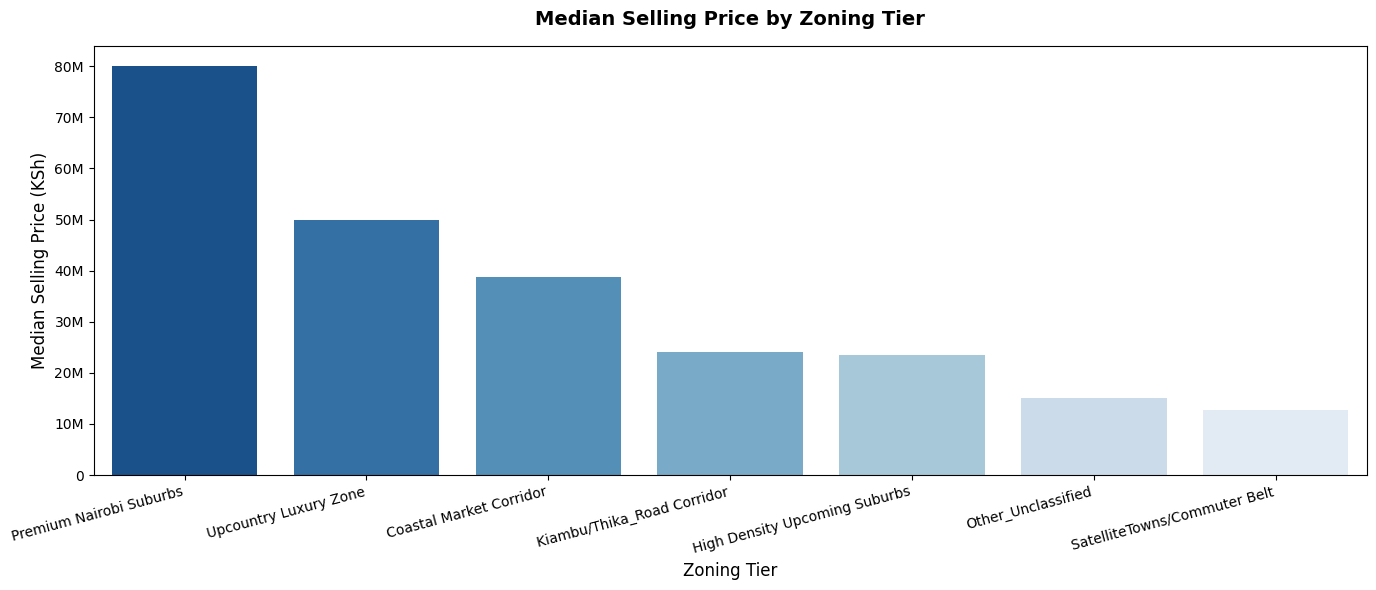

In [14]:

selling_price_by_zone = df.groupby("zoning_tier")["selling price"].median().sort_values(ascending=False)
plt.figure(figsize=(14, 6))
sns.barplot(data=selling_price_by_zone.reset_index(), x="zoning_tier", y="selling price", palette="Blues_r")
plt.title("Median Selling Price by Zoning Tier", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Zoning Tier", fontsize=12)
plt.ylabel("Median Selling Price (KSh)", fontsize=12)
plt.xticks(rotation=15, ha='right') # Slightly tilts labels to prevent overlapping text

import matplotlib.ticker as ticker
formatter = ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.0f}M' if x >= 1e6 else f'{x:.0f}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()


In [16]:
df.head()

,selling price,no_of_bedrooms,has_servant_quarters,property_type,clean_location,zoning_tier
0,130000000,6.0,0,Villa,Kiambu Road,Kiambu/Thika_Road Corridor
1,26950000,4.0,1,Townhouse,Kiambu Road,Kiambu/Thika_Road Corridor
2,16000000,4.0,0,Villa,Ongata Rongai,SatelliteTowns/Commuter Belt
3,45000000,5.0,0,Villa,Ngong,SatelliteTowns/Commuter Belt
4,72000000,5.0,0,Townhouse,Lavington,Premium Nairobi Suburbs


/tmp/ipykernel_28742/447689514.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=no_of_bedrooms_zoning.reset_index(), x="zoning_tier", y="no_of_bedrooms", palette="Blues_r")


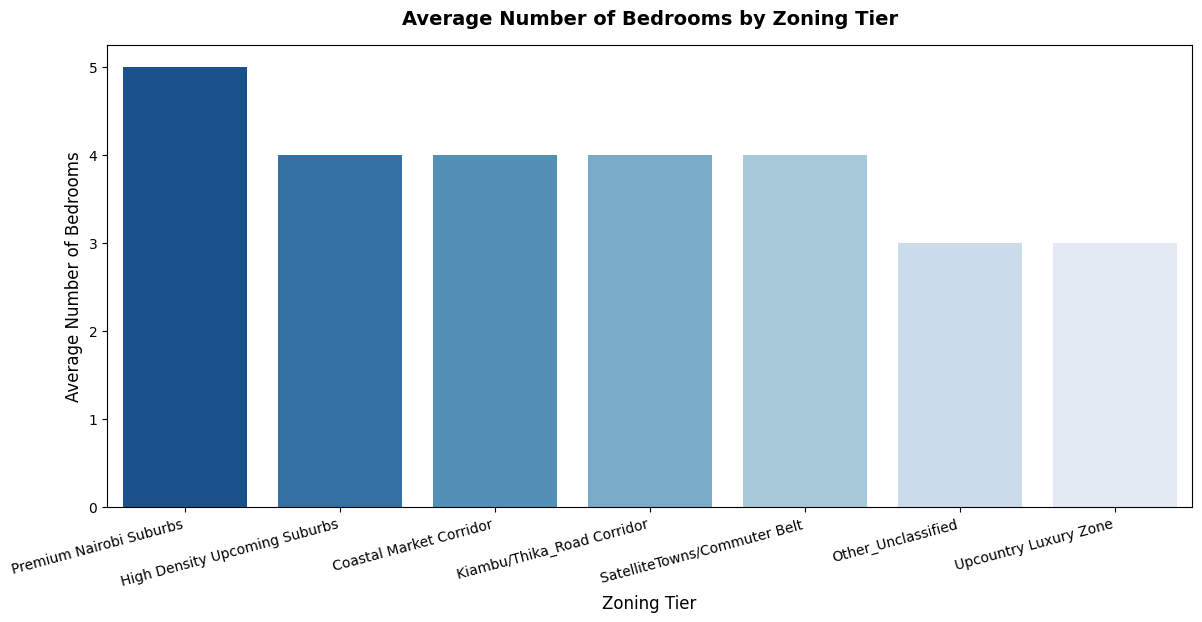

In [21]:
plt.figure(figsize=(14, 6))
no_of_bedrooms_zoning = df.groupby("zoning_tier")["no_of_bedrooms"].median().sort_values(ascending=False)
sns.barplot(data=no_of_bedrooms_zoning.reset_index(), x="zoning_tier", y="no_of_bedrooms", palette="Blues_r")
plt.xticks(rotation=15, ha='right')
plt.title("Average Number of Bedrooms by Zoning Tier", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Zoning Tier", fontsize=12)
plt.ylabel("Average Number of Bedrooms", fontsize=12)
plt.show()

/tmp/ipykernel_28742/1682532511.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ps.groupby('clean_location')['selling price'].median().sort_values(ascending=False).reset_index(), x='clean_location', y='selling price', palette='Blues_r')


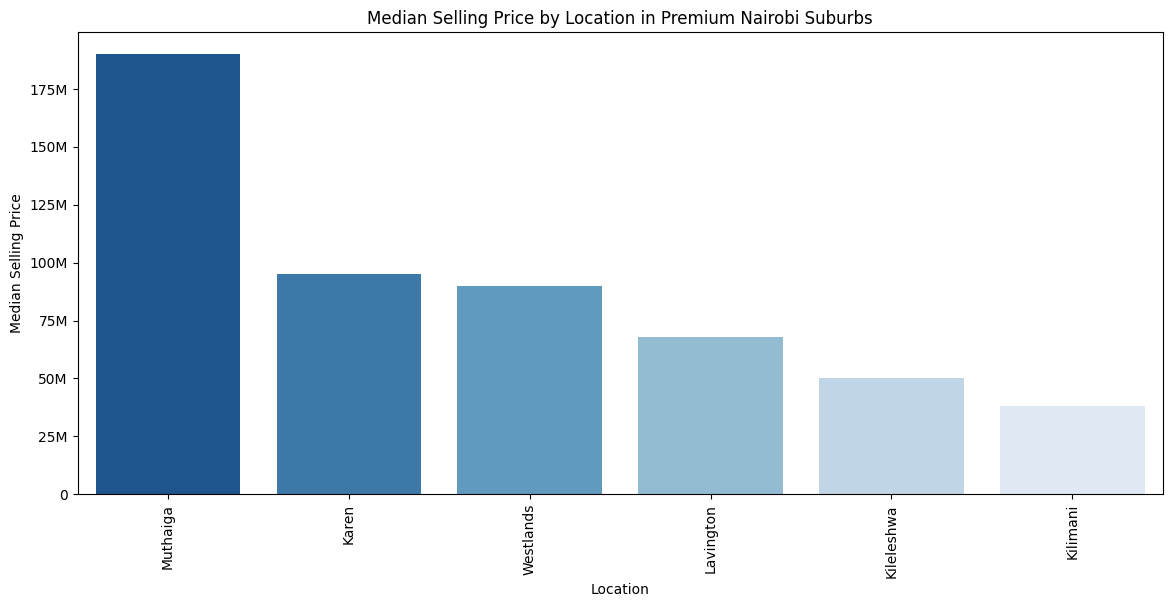

In [31]:
df_ps=df[df['zoning_tier'] == 'Premium Nairobi Suburbs']
plt.figure(figsize=(14, 6))
sns.barplot(data=df_ps.groupby('clean_location')['selling price'].median().sort_values(ascending=False).reset_index(), x='clean_location', y='selling price', palette='Blues_r')
formatter = ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.0f}M' if x >= 1e6 else f'{x:.0f}')
plt.gca().yaxis.set_major_formatter(formatter)
plt.xticks(rotation=90)
plt.title('Median Selling Price by Location in Premium Nairobi Suburbs')
plt.xlabel('Location')
plt.ylabel('Median Selling Price')
plt.show()


/tmp/ipykernel_28742/558787431.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




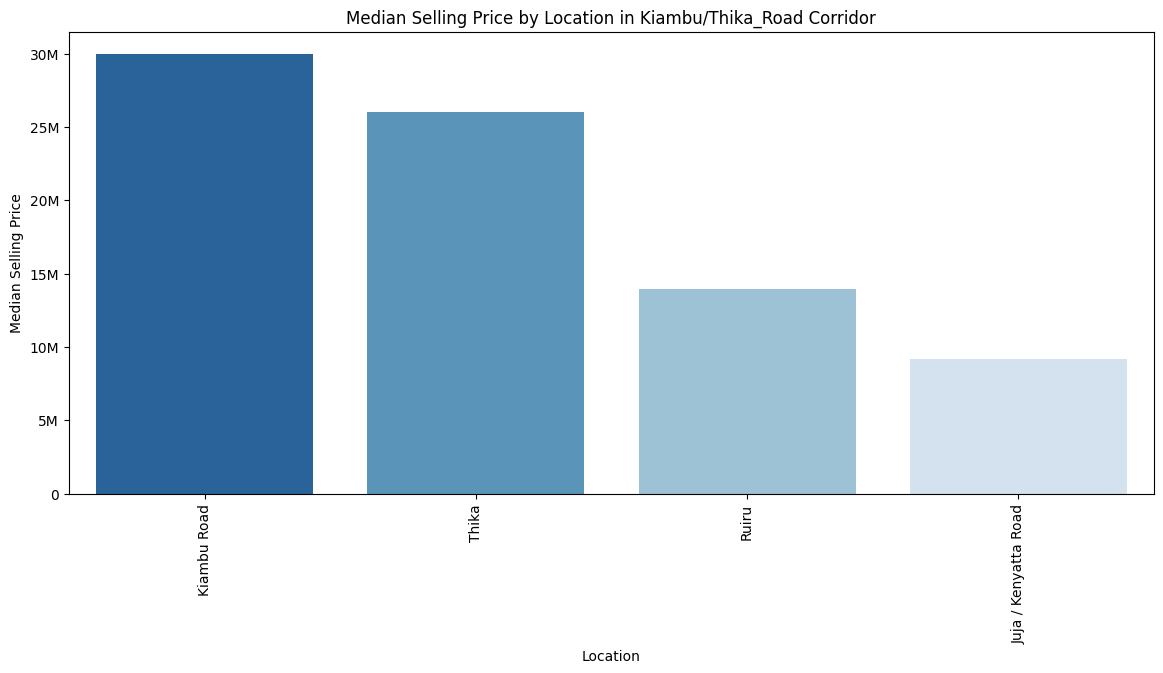

In [42]:
df_tk = df[df['zoning_tier']=='Kiambu/Thika_Road Corridor']
plt.figure(figsize=(14, 6))
sns.barplot(data=df_tk.groupby('clean_location')['selling price'].median().sort_values(ascending=False).reset_index(), x='clean_location', y='selling price', palette='Blues_r')
formatter = ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.0f}M' if x >= 1e6 else f'{x:.0f}')
plt.gca().yaxis.set_major_formatter(formatter)
plt.xticks(rotation=90)
plt.title('Median Selling Price by Location in Kiambu/Thika_Road Corridor')
plt.xlabel('Location')
plt.ylabel('Median Selling Price')
plt.show()

In [58]:
# Removing Outliers
def remove_global_outliers(df, column_name='selling price'):
    """
    Removes rows where the column value is an outlier based on the 1.5 * IQR rule.
    """
    # 1. Calculate the 25th (Q1) and 75th (Q3) percentiles
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)

    # 2. Compute the Interquartile Range (IQR)
    IQR = Q3 - Q1

    # 3. Define lower and upper boundaries
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


    print(f"Lower Bound: {lower_bound:.2f} M | Upper Bound: {upper_bound:.2f} M")

    # 4. Filter the dataframe
    cleaned_df = df[(df[column_name] >= lower_bound) & (df[column_name] <= upper_bound)]

    # How many were dropped
    rows_removed = len(df) - len(cleaned_df)
    print(f"Removed {rows_removed} outlier listings from the dataset.\n")

    return cleaned_df


df_cleaned = remove_global_outliers(df, column_name='selling price')
df_cleaned.head()

Lower Bound: -78750625.00 M | Upper Bound: 175250375.00 M
Removed 91 outlier listings from the dataset.



,selling price,no_of_bedrooms,has_servant_quarters,property_type,clean_location,zoning_tier
0,130000000,6.0,0,Villa,Kiambu Road,Kiambu/Thika_Road Corridor
1,26950000,4.0,1,Townhouse,Kiambu Road,Kiambu/Thika_Road Corridor
2,16000000,4.0,0,Villa,Ongata Rongai,SatelliteTowns/Commuter Belt
3,45000000,5.0,0,Villa,Ngong,SatelliteTowns/Commuter Belt
4,72000000,5.0,0,Townhouse,Lavington,Premium Nairobi Suburbs


In [59]:
print(df.shape)
print(df_cleaned.shape)

(1848, 6)
(1757, 6)


In [61]:
for column in df.columns:
    print(f"--- Value Counts for: {column} ---")
    print(df[column].value_counts())
    print("\n" + "="*40 + "\n")


--- Value Counts for: selling price ---
selling price
65000000     48
75000000     47
85000000     42
55000000     40
45000000     38
             ..
45800000      1
10050000      1
7499000       1
199000000     1
79000000      1
Name: count, Length: 292, dtype: int64


--- Value Counts for: no_of_bedrooms ---
no_of_bedrooms
4.0     788
5.0     457
3.0     408
6.0     117
7.0      34
2.0      24
1.0       8
8.0       6
9.0       3
10.0      2
Name: count, dtype: int64


--- Value Counts for: has_servant_quarters ---
has_servant_quarters
0    1723
1     125
Name: count, dtype: int64


--- Value Counts for: property_type ---
property_type
Villa        1297
Townhouse     551
Name: count, dtype: int64


--- Value Counts for: clean_location ---
clean_location
Westlands                      362
Lavington                      198
Kiambu Road                    133
Kitengela                      115
Ruiru                          112
Nyali                          111
Karen                    

In [62]:
df_cleaned.to_csv("Cleaned_Kenyan_Real_Estate_Prices.csv",index=False)

print('csv file saved successfully')

csv file saved successfully
